# (17) leapfrog: (16x8, 32.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'leapfrog|lin')

cfg_vae['seq_len'] = 16
cfg_vae['n_iters_inner'] = 4
cfg_tr['kl_beta'] = 32.0

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

vH16_t-16×4_b-4_z-[512]_cl-8,7_<leapfrog|lin>
b200-ep300-lr(0.002)_beta(32:0.1)_temp(0.01:0.5)_gr(500)_(2025_02_20,11:35)

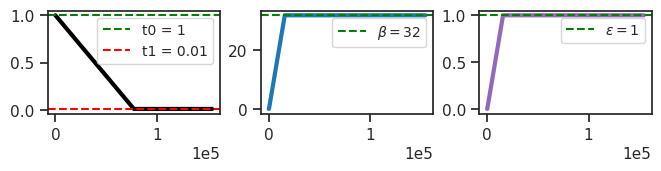

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
# tr.model.layer.update_n_exp(3.0)
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=4, eps=1)

In [7]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.exp()

(torch.Size([1, 512]), tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [8]:
# cm = f"nexp-(p:1e-3)_clamp-(u:{tr.model.cfg.clamp_u:0.2g},du:{tr.model.cfg.clamp_du:0.2g})"
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 276.264901: 100%|██| 300/300 [13:03:44<00:00, 156.75s/it]


epoch # 300, avg loss: 269.830722: 100%|████| 300/300 [2:39:06<00:00, 31.82s/it]


In [9]:
print(tr.model.layer.n_exp)

tensor([12, 18, 25, 32, 38, 41, 43, 43, 44, 44, 44, 44, 44, 44, 44, 44],
       device='cuda:1', dtype=torch.int32)

In [10]:
tr.model.layer.log_dt.exp(), tr.model.layer.log_gamma.exp()

(tensor([1.7896], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([67.1000], device='cuda:1', grad_fn=<ExpBackward0>))

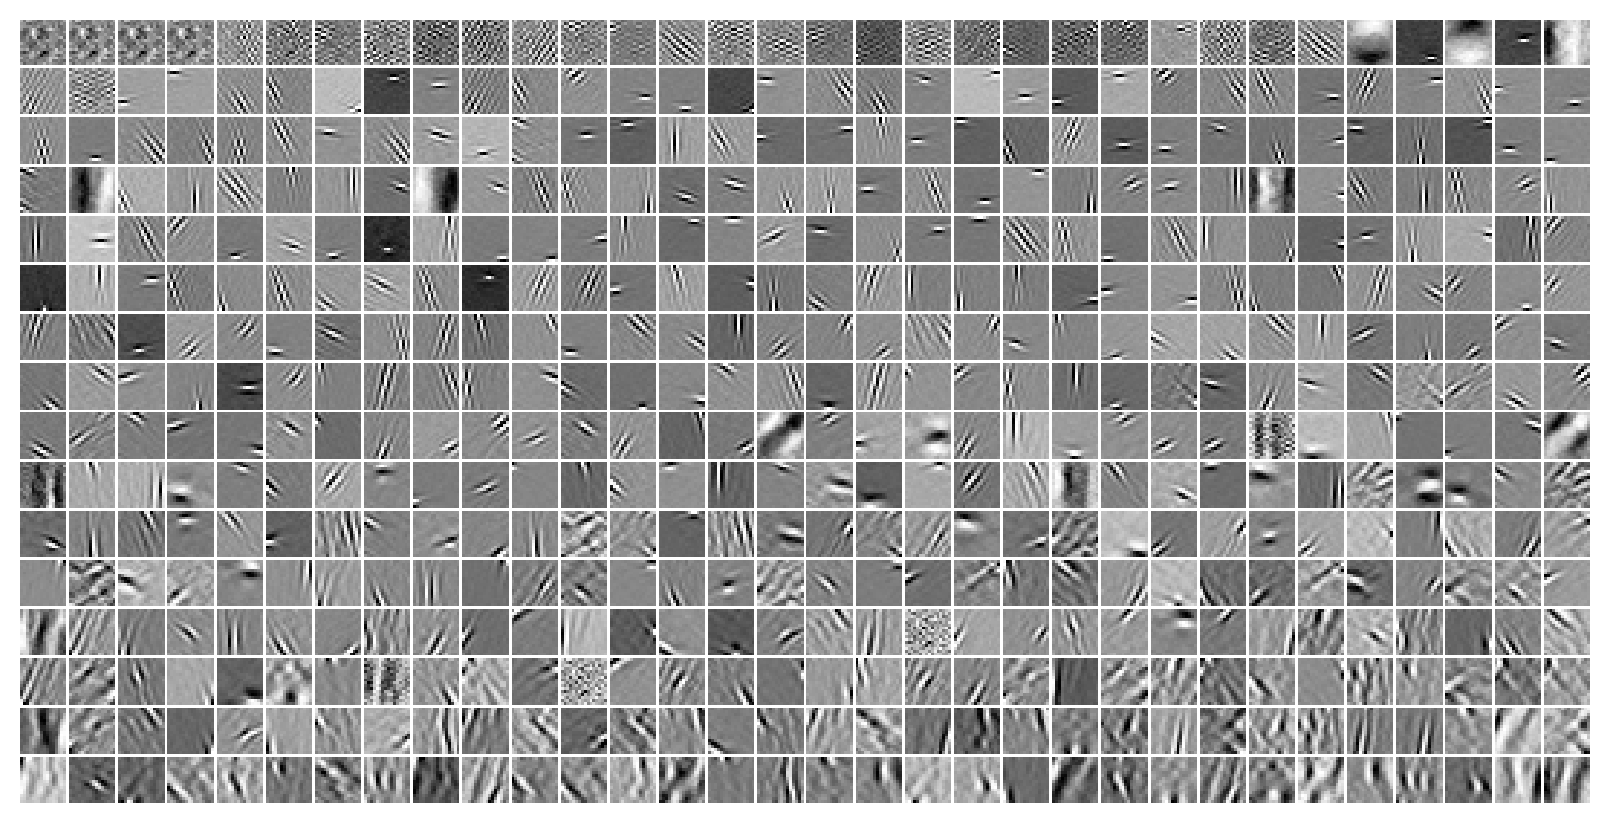

In [11]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

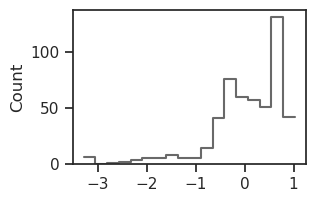

In [12]:
histplot(u0, color='dimgrey');

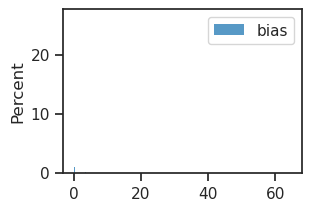

In [13]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

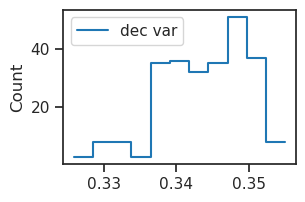

In [14]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

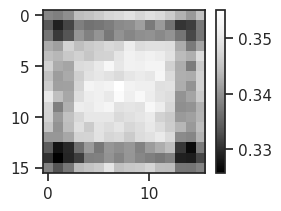

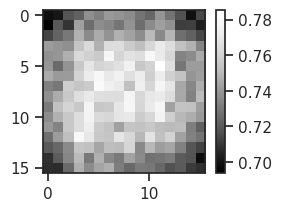

In [15]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|██████████████████████████████████| 2/2 [04:30<00:00, 135.37s/it]


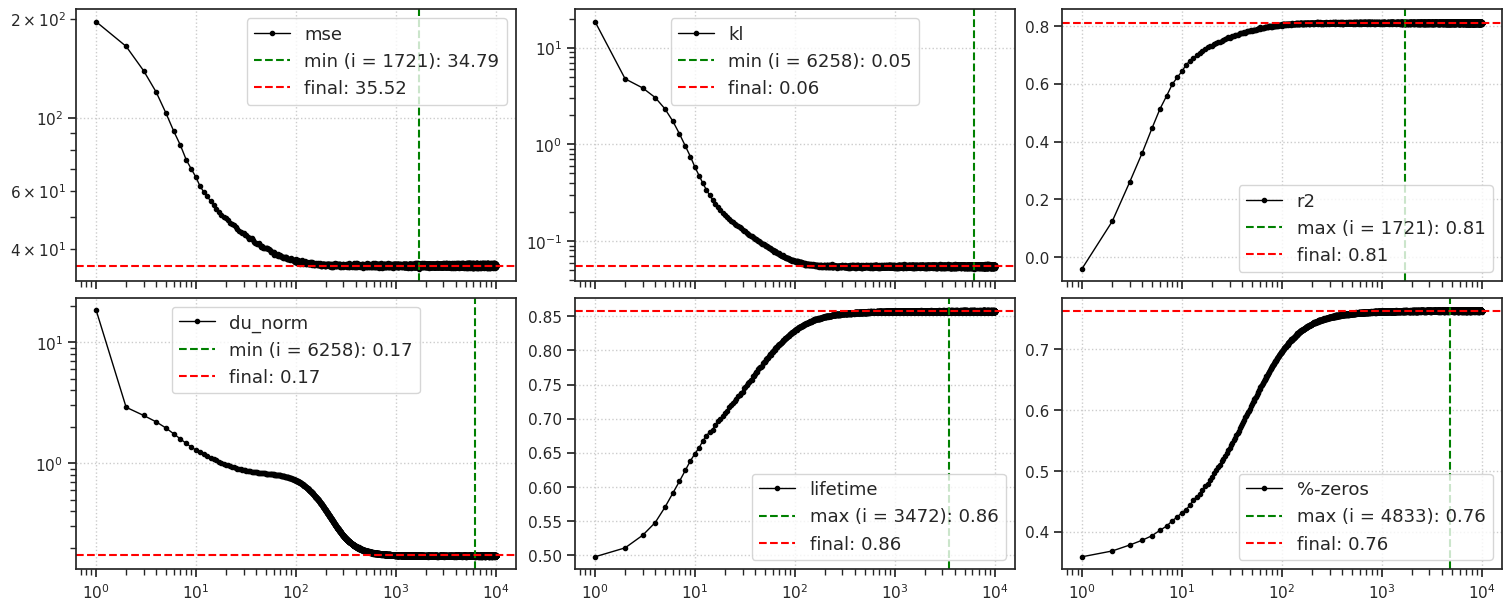

CPU times: user 4min 39s, sys: 2.71 s, total: 4min 41s
Wall time: 4min 41s


In [16]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.82s/it]


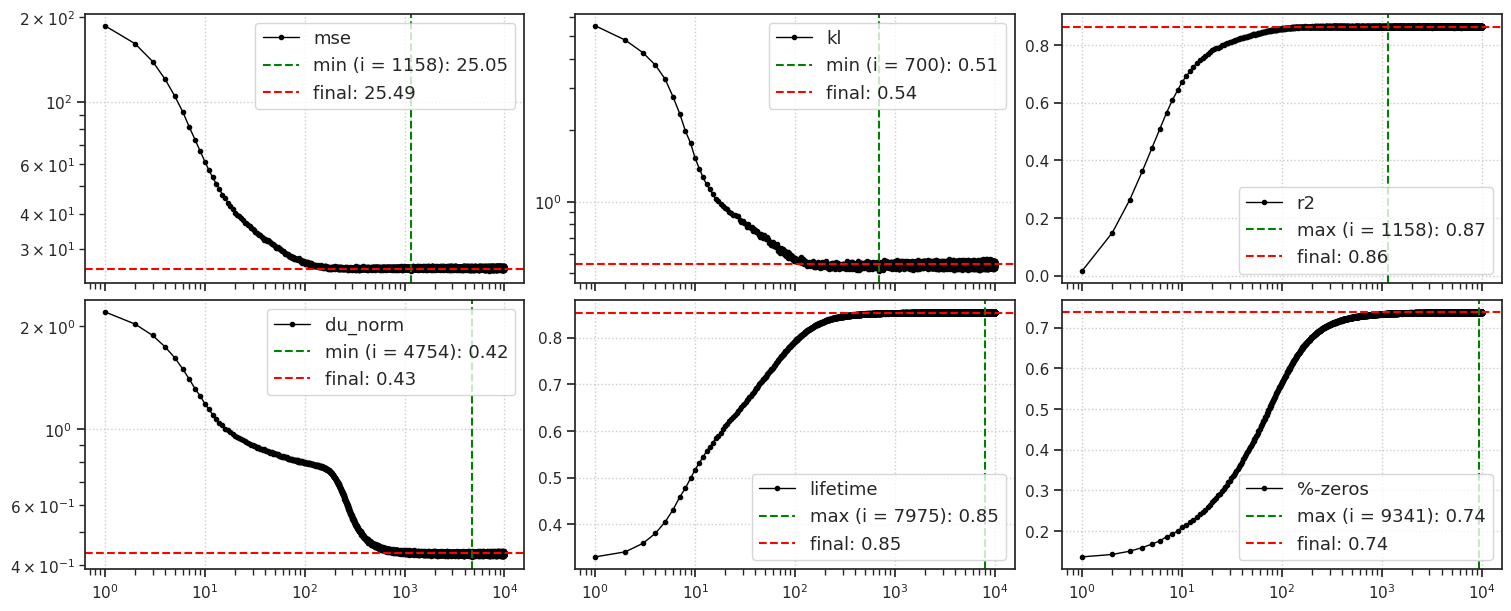

CPU times: user 50 s, sys: 2.79 s, total: 52.8 s
Wall time: 52.8 s


In [15]:
### Was: n_exp p = 1e-6

## output

In [17]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

In [21]:
final_spks = tonp(output['samples'][:, -1].ravel()).astype(int)
life, _, portions = sparse_score(final_spks.reshape(-1, 1), cutoff=0.01)

print(life)
print(portions)

[0.8647816]

{'0': 76.5, '1': 7.1, '2': 4.7, '3': 3.4, '4': 2.5, '5': 1.7, '6': 1.2, '7': 0.8, '8+': 2.1}

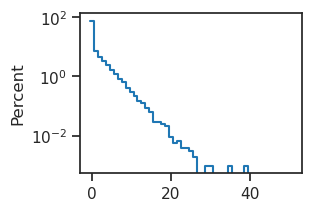

In [22]:
fig, ax = create_figure()

histplot(final_spks, stat='percent', bins=np.linspace(0, 51, 52) - 0.5)
ax.set(yscale='log');

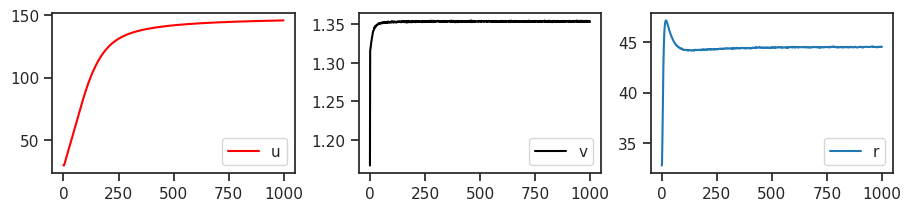

In [23]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

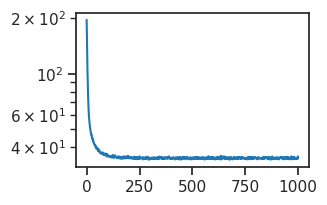

tensor([35.2285, 34.9788, 35.3255, 34.7661, 35.7518], device='cuda:1')

In [24]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

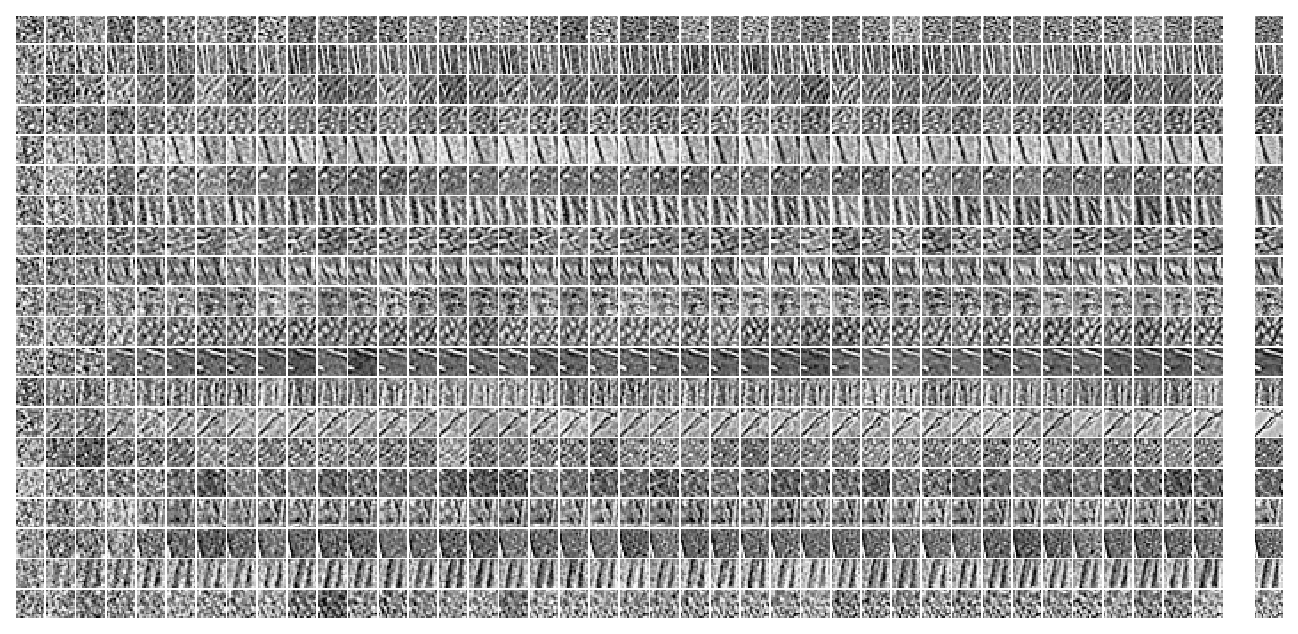

In [25]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

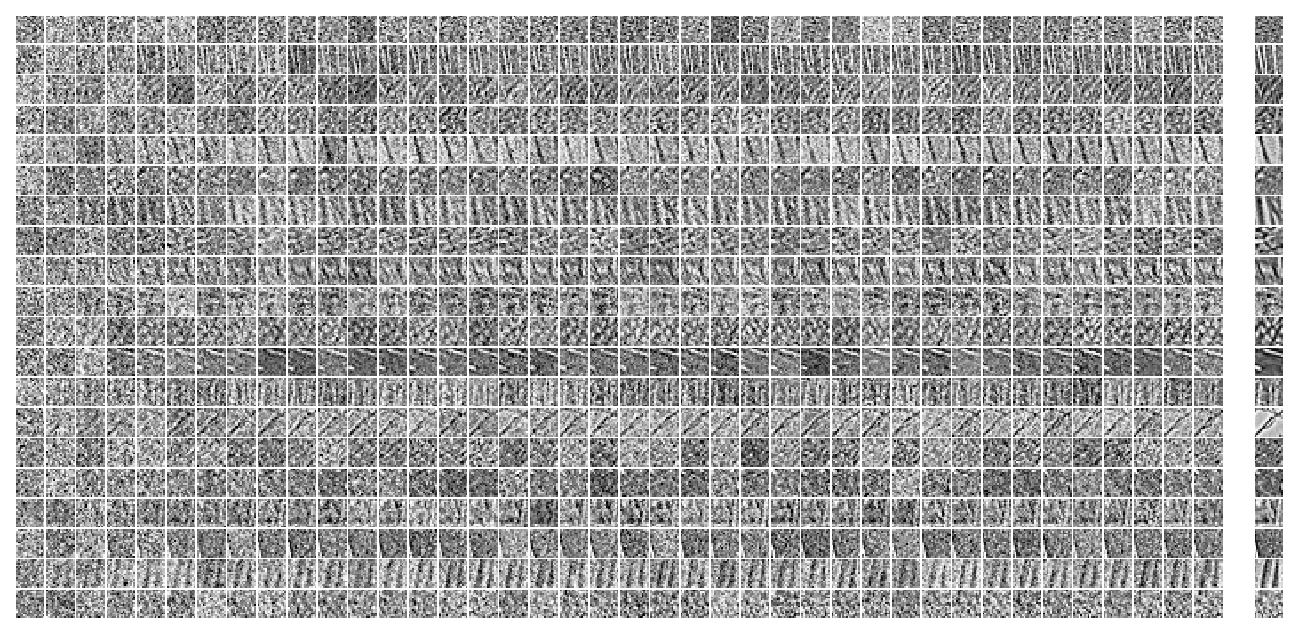

In [26]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)